# (urbanair-dm) Evaluate and analyse (minimal working example)

Automatic Lidar and Ceilometer (ALC) stats evaluation. The data were created by Dana Looschelders et al. for the *urbisphere* project (see data attributes).

Creator: Matthias Zeeman, University of Freiburg, for the UrbanAIR project.

### Included in this Notebook

1. How to read and explore the (intermediate, final) results data (**L2**)

In [1]:
import glob
import io
import itertools
import json
import math
import os
import pickle
import re
import sys
import warnings
from collections import OrderedDict, defaultdict
from pathlib import Path

import bottleneck
import markdown
import numpy as np
import pandas as pd
import plotly.express as px
import xarray as xr
import zarr
from IPython.display import HTML
from IPython.display import Image as IPImage
from PIL import Image
from plotly.express.colors import sample_colorscale
from tqdm.notebook import tqdm

In [2]:
sys.path.append(str(Path("../src/").resolve()))
from urbanair_dm_lib import *

In [3]:
repository_cache_path = "../data/repositories/"  # download folder
repository_urls = [
    "https://doi.org/10.5281/zenodo.17953079",
]

repository_path = "../data/"  # source/destination folder
repository_path_L1 = [
    "../data/ALC/L0/",
]
repository_path_L2 = [
    "../data/ALC/L2B/",
]

## Download repositories

The following commands downloads the repositories and copies the selected files to a shared location. Skip or remove if you have manually downloaded and organised your data. This is typically only needed once, but Zenodo timeouts happen occasionally and retries are required. 

In [ ]:
if get_zenodo_repository(repository_cache_path, repository_urls):
    unpack_zenodo_repository(
        repository_cache_path,
        repository_urls,
        destination_path=repository_path,
    )

# L2

In [4]:
# production files
fn_list, fn_dict = input_files(repository_path_L2, "raw2l1_set*.nc")

Found 17 files


In [5]:
ds, global_attrs_dict, _ = datastore(fn_dict)

  0%|          | 0/6 [00:00<?, ?it/s]

In [6]:
# consolidate datastore for plotting
station_info = [
    re.findall(r"(.*?)\s?\(([A-Z]{6})\).*?", s)[0]
    for s in ds["station_name"].values.tolist()
]

plot_ds = (
    ds.assign_coords(
        {
            v: ds[v].mean(dim="time")
            for v in [
                n
                for n in ds.data_vars
                for m in ["station", "sensor"]
                if n.startswith(m)
            ]
        }
    )
    .reset_index("station_name")
    .rename_vars(
        {
            "station_latitude": "station_lat",
            "station_longitude": "station_lon",
            "sensor_height": "station_height",
        }
    )
    .rename_dims({"station_name": "station"})
    .assign_coords(
        station_name=("station", [n[0] for n in station_info]),
        station_id=("station", [n[1] for n in station_info]),
    )
    .transpose(..., "time")
    .sortby("station_lat", ascending=True)
    .assign_attrs(
        {"production_level": "L2B", "production_profile": "set(fr.paris,ALC,2022_2024)"}
    )
)
plot_ds = xr_reindex(plot_ds).reset_index('station')

# export
# plot_ds.to_netcdf('../data/ALC/L2B/ALC_L2B_data_consolidated.nc')

# final
plot_ds = plot_ds.set_index(station=["station_id"])

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


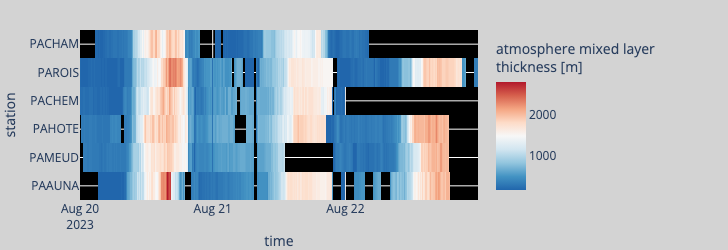

In [7]:
fig = plot_da(plot_ds["MLH"], range_color=None)
fig.update_layout(margin_l=80, margin_r=250, height=250).show()

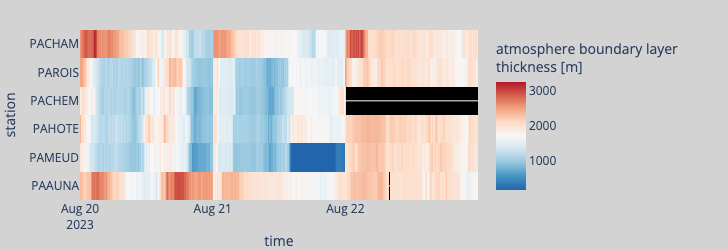

In [8]:
fig = plot_da(plot_ds["ABLH"], range_color=None)
fig.update_layout(margin_l=80, margin_r=250, height=250).show()

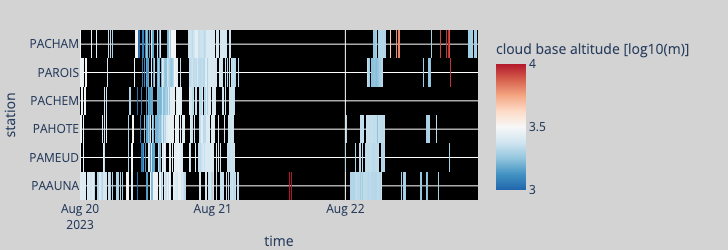

In [9]:
fig = plot_da(
    np.log10(plot_ds["cloud_base_altitude"]).assign_attrs(
        units=f"log10({plot_ds["cloud_base_altitude"].attrs['units']})"
    ),
    range_color=[3, 4],
)
fig.update_layout(margin_l=80, margin_r=250, height=250).show()

### Metadata

In [10]:
# display metadata context, if applicable
HTML(
    json.dumps(
        {
            f"<b>{k}</b>": str(v)
            .replace("\n", " ")
            .replace("<p>", "")
            .replace("</p>", "")
            .encode("ascii", "xmlcharrefreplace")
            .decode("ascii")
            for k, v in ds.attrs.items()
        },
        indent=4,
        separators=(",<br>", ": "),
    )
)

# L0/L1

In [11]:
# t.b.d.

In [12]:
# jupyter notebook context
HTML(hello_world())